In [1]:
library(ggplot2)
library(patchwork)
library(data.table)
theme_set(theme_bw())

# Source - https://stackoverflow.com/a
# Posted by dfrankow
# Retrieved 2026-01-16, License - CC BY-SA 3.0

options(repr.matrix.max.rows=600, repr.matrix.max.cols=200)

options(repr.plot.width = 10)

In [2]:
ranks = c("genus", "family", "order", "class")
communities = paste0('sample', seq(from = 0, to = 1))
reps = seq(0, 3)

# Diamond percent identity distribution

In [39]:
d1 = data.table(expand.grid(community = communities, rank = ranks, rep = reps))
d1[, rank := factor(rank, ranks)]
readarchive = function(community, rank, rep){
    to_read <- paste0('output_singlem_dev/singlem_dev/', rank, "/", community,'-', rep, '.sma')
    m <- jsonlite::read_json(to_read)
    stopifnot(m$fields[14] == "percent_identities")
    setcolorder(
        data.table(purrr::list_rbind(
            purrr::map(
                m$otus,
                \(x) {
                    pc_id <- unlist(x[[14]])
                    data.frame(percent_id = pc_id,
                               marker = if(length(pc_id)) x[[1]])
                }
            ),
            names_to = "otu"
        )),
        c("otu", "percent_id", "marker")
    )
}
d2 = d1[, readarchive(community, rank, rep), by = .(community, rank, rep)]
#d2[, rank := factor(rank, c("genus", "family", "class", "order"), c("genus", "family", "order", "class"))]

In [40]:
pid_p <- ggplot(d2, aes(percent_id, colour = rank, linetype = community)) +
  geom_freqpoly(binwidth = 2)

In [41]:
truth_profiles = data.table(expand.grid(community=communities, rank = ranks, rep = reps))
truth_profiles[, rank := factor(rank, ranks)]
truth_profiles2 = truth_profiles[, fread(paste('truths/',rank, '/', community,'-', rep, '.condensed',sep='')), by=.(community, rank, rep)]
truth_profiles2[, "sample" := NULL]
#truth_profiles2[, rank := factor(rank, c("genus", "family", "class", "order"), c("genus", "family", "order", "class"))]

In [42]:
novelty_class <- function(x) factor(stringr::str_extract(x, "([dpcofgs])__[^;]+$", group = 1), c("d", "p", "c", "o", "f", "g", "s"))
n <- truth_profiles2[, .(coverage = sum(coverage)), by=.(community, rank, rep, novelty = novelty_class(taxonomy))]
n <- n[novelty != "s",]

In [44]:
n_p <- ggplot(n, aes(novelty, coverage, fill = community)) +
    geom_col(position = "dodge2")

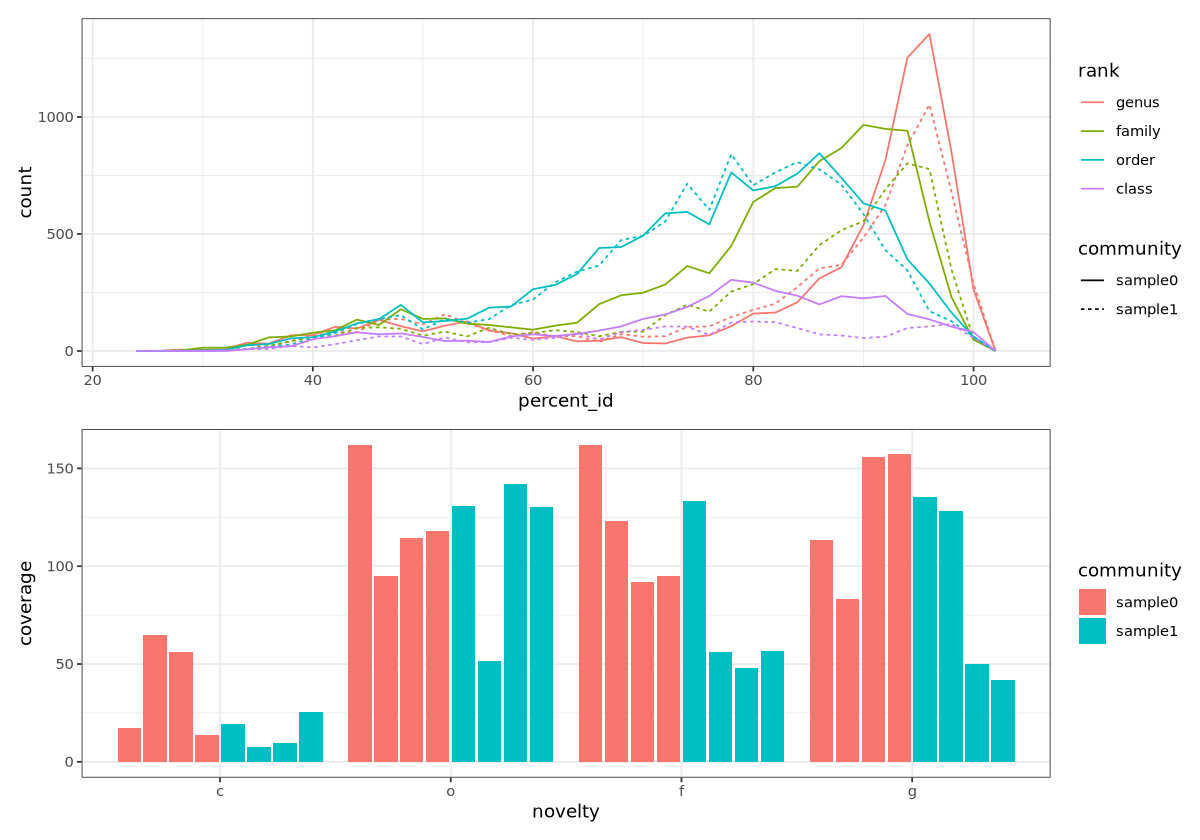

In [45]:
pid_p / n_p

In [51]:
pid_p_mrk <- ggplot(d2, aes(percent_id, colour = factor(marker), linetype = community)) +
  geom_freqpoly(binwidth = 2) +
  facet_wrap(vars(rank)) +
  scale_colour_discrete(guide = "none")

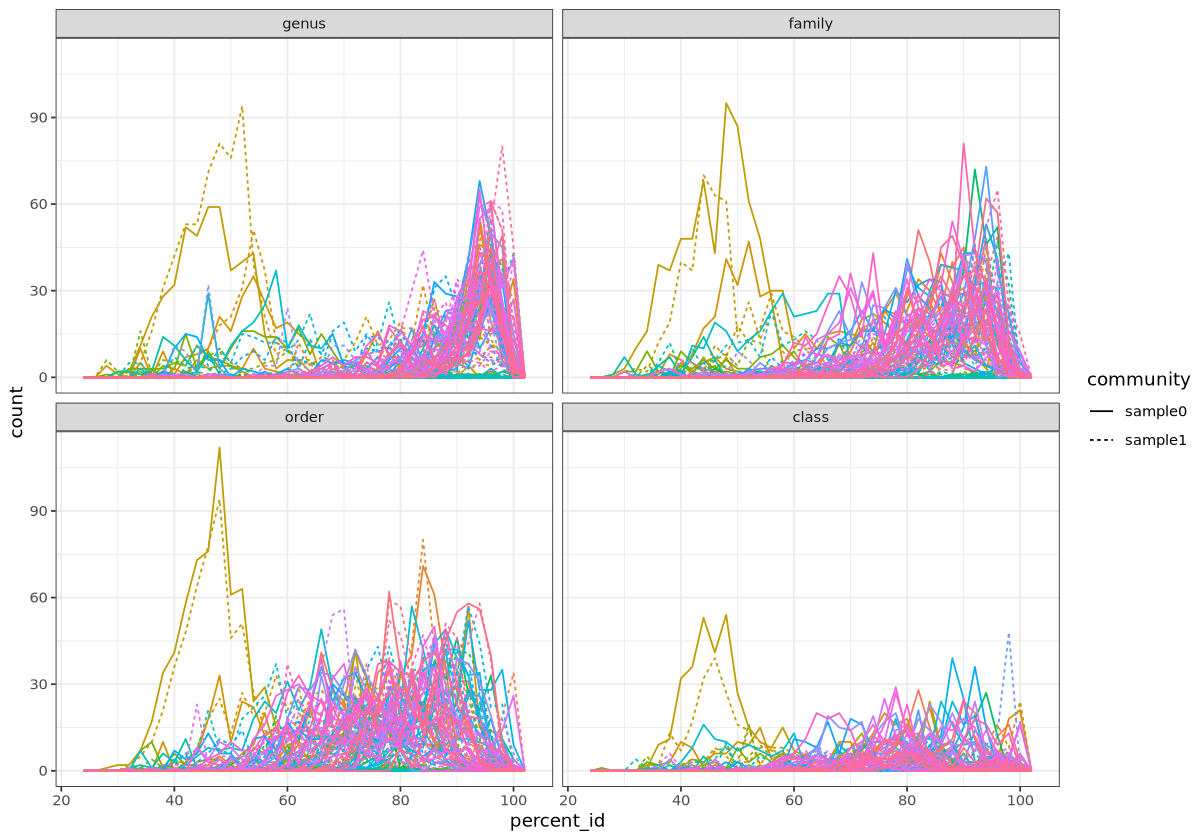

In [52]:
pid_p_mrk

### Check relationship of percent_id to coverage

In [18]:
npid <- d2[n, on = c("community", "rank", "rep")]

In [26]:
npid[1:5,]

community,rank,rep,otu,percent_id,novelty,coverage
<fct>,<fct>,<int>,<int>,<dbl>,<fct>,<dbl>
sample0,genus,0,1,98.0,g,113.3747
sample0,genus,0,2,95.9,g,113.3747
sample0,genus,0,2,95.9,g,113.3747
sample0,genus,0,5,100.0,g,113.3747
sample0,genus,0,5,100.0,g,113.3747


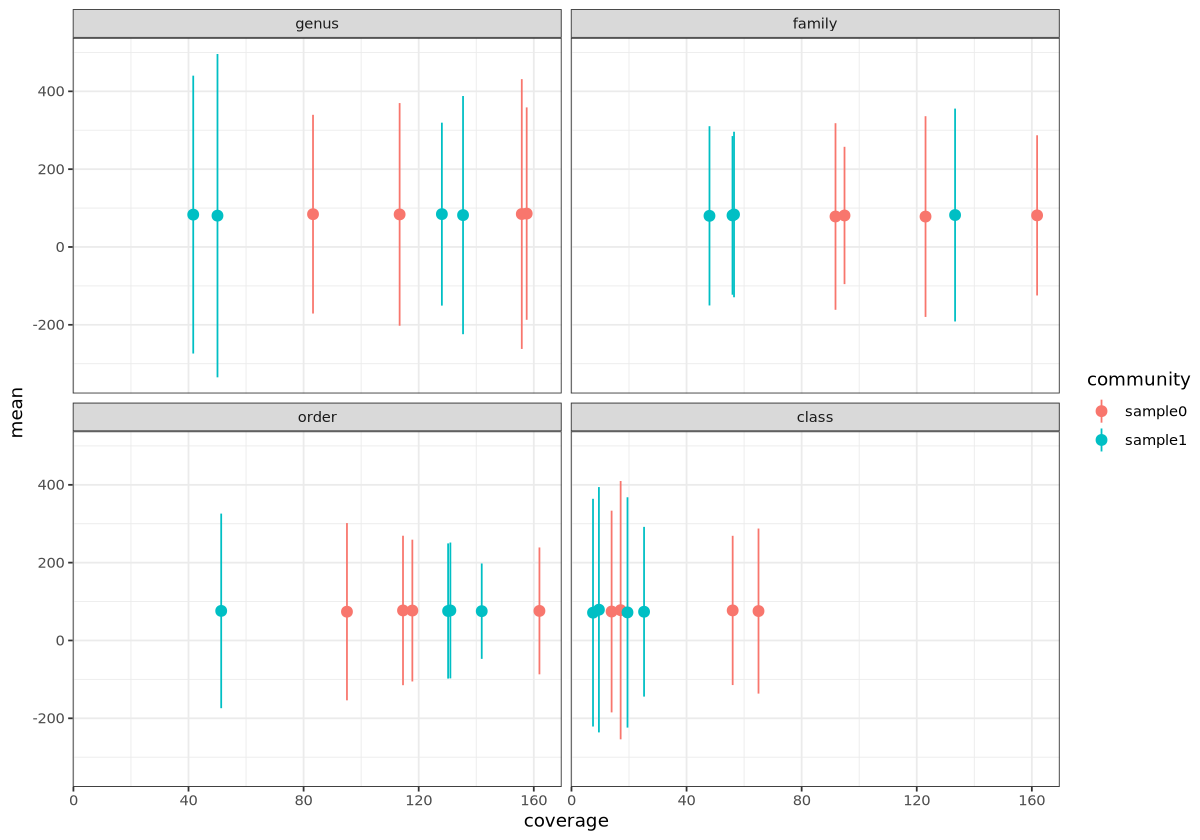

In [31]:
ggplot(
    npid[, .(mean = mean(percent_id), var = var(percent_id)), by = .(community, coverage, rep, rank)],
    aes(coverage,  mean, ymin = mean - var, ymax = mean + var, colour = community)
) +
    geom_pointrange() +
    facet_wrap(vars(rank))